
# Notebook 2

**Diplomado, Módulo II: Técnicas Estadísticas**


In [1]:
# Librerías que usaremos a lo largo de todo el notebook
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from math import comb

np.random.seed(42)  # para que los resultados sean reproducibles



# 1. Variables aleatorias discretas

Una **variable aleatoria discreta** $X$ es una función que le asigna un número (de un conjunto finito o infinito numerable) a cada resultado de un experimento aleatorio. Su comportamiento se describe con una **función de masa de probabilidad (pmf)**:

$$f_X(k) = \mathbb{P}(X=k),$$

que debe cumplir $f_X(k)\ge 0$ para todo $k$, y $\sum_k f_X(k) = 1$.

A partir de $f_X$ se definen la **esperanza** (el valor promedio a largo plazo) y la **varianza** (qué tanto se dispersan los valores respecto a la esperanza):

$$\mathbb{E}[X] = \sum_k k\, f_X(k), \qquad \text{Var}(X) = \mathbb{E}[X^2]-(\mathbb{E}[X])^2.$$

A continuación revisamos, una por una, las distribuciones discretas más importantes.



## 1.1 Variable aleatoria uniforme discreta

Una variable aleatoria $X$ tiene distribución uniforme discreta sobre $\{x_1,\dots,x_n\}$ si todos sus valores son igualmente probables:

$$f_X(k) = \begin{cases} \dfrac{1}{n} & \text{si } k \in \{x_1,\dots,x_n\} \\ 0 & \text{en otro caso}\end{cases}$$

**Notación:** $X\sim \text{Unif}(x_1,\dots,x_n)$.

**Propiedades:**
$$\mathbb{E}[X] = \frac{x_1+x_n}{2}, \qquad \text{Var}(X) = \frac{(x_n-x_1+1)^2-1}{12}.$$

**Ejemplo.** Sea $X$ el resultado de lanzar un dado justo, es decir $X\sim \text{Unif}(1,\dots,6)$. Vamos a graficar su función de masa de probabilidad y a comprobar, con la definición directa, que las fórmulas de esperanza y varianza son correctas.


Esperanza (calculo directo) : 3.5
Esperanza (formula)         : 3.5
Varianza  (calculo directo) : 2.9167
Varianza  (formula)         : 2.9167


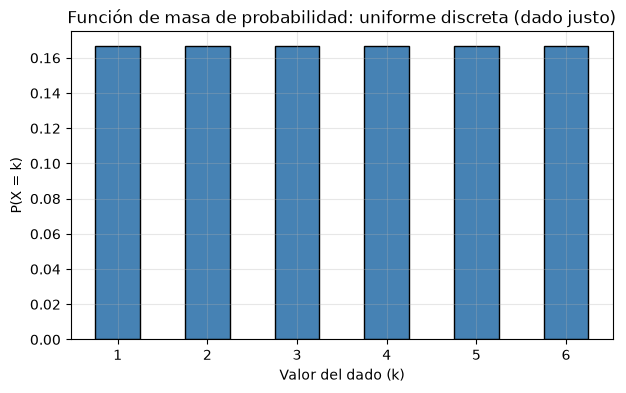

In [2]:
# Variable aleatoria uniforme discreta: un dado justo, X en {1,...,6}
valores = np.arange(1, 7)
n_valores = len(valores)
pmf_unif = np.full(n_valores, 1 / n_valores)  # cada valor tiene probabilidad 1/6

# Esperanza y varianza calculadas directamente con la definicion
E_directa = np.sum(valores * pmf_unif)
Var_directa = np.sum((valores - E_directa) ** 2 * pmf_unif)

# Esperanza y varianza usando las formulas de la uniforme discreta
E_formula = (valores[0] + valores[-1]) / 2
Var_formula = ((valores[-1] - valores[0] + 1) ** 2 - 1) / 12

print("Esperanza (calculo directo) :", E_directa)
print("Esperanza (formula)         :", E_formula)
print("Varianza  (calculo directo) :", round(Var_directa, 4))
print("Varianza  (formula)         :", round(Var_formula, 4))

# Graficamos la funcion de masa de probabilidad
plt.figure(figsize=(7, 4))
plt.bar(valores, pmf_unif, color='steelblue', edgecolor='black', width=0.5)
plt.xlabel('Valor del dado (k)')
plt.ylabel('P(X = k)')
plt.title('Función de masa de probabilidad: uniforme discreta (dado justo)')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** Una rifa tiene boletos numerados del $00$ al $99$ (100 boletos). El premio en pesos se calcula como $X = Y+1$, donde $Y$ es el número del boleto ganador. Calcula $\mathbb{E}[X]$, $\text{Var}(X)$, y la probabilidad de que el premio sea mayor a \$80.


In [3]:
# Ejercicio: rifa con boletos del 00 al 99. El premio es X = Y + 1
premios = np.arange(1, 101)  # X toma valores 1,2,...,100
pmf_rifa = np.full(100, 1 / 100)

E_rifa = np.sum(premios * pmf_rifa)
Var_rifa = np.sum((premios - E_rifa) ** 2 * pmf_rifa)
prob_mayor_80 = np.sum(pmf_rifa[premios > 80])

print("E[X] (premio esperado)        :", E_rifa)
print("Var(X)                        :", Var_rifa)
print("P(premio > 80)                :", prob_mayor_80)


E[X] (premio esperado)        : 50.5
Var(X)                        : 833.2500000000001
P(premio > 80)                : 0.20000000000000004



En promedio uno se esperaría ganar \$50.50$ con esta rifa, aunque la varianza sale bastante alta (833.25), o sea que el premio se mueve muchísimo de un boleto a otro. Y nada más el 20% de los boletos te dan más de \$80$, así que el premio grande es más la excepción que la regla.



## 1.2 Variable aleatoria Bernoulli

Modela un experimento con solo dos resultados posibles: éxito (1) o fracaso (0), con probabilidad de éxito $p\in(0,1)$:

$$f_X(k) = \begin{cases} p & k=1 \\ 1-p & k=0\end{cases}, \qquad X\sim \text{Ber}(p).$$

**Propiedades:** $\mathbb{E}[X]=p$, $\text{Var}(X)=p(1-p)$.

Se usa para modelar situaciones de sí/no: si un cliente compra o no, si un componente falla o no, si un paciente mejora o no, etc.

**Ejemplo.** Un vendedor cierra una venta con probabilidad $p=0.35$ en cada llamada.


f(0) = P(no vende) = 0.6499999999999998
f(1) = P(vende)    = 0.35
E[X] = 0.35  (coincide con p)
Var(X) = 0.2275  (coincide con p(1-p) = 0.2275 )


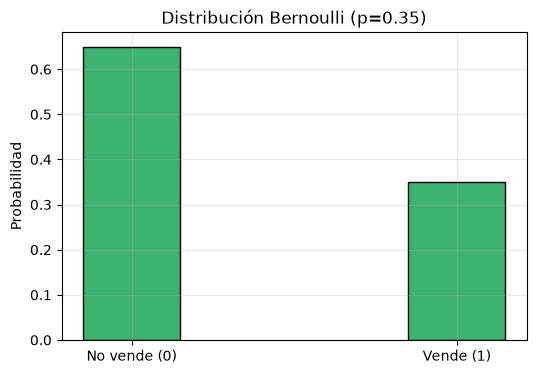

In [4]:
from scipy.stats import bernoulli

p = 0.35  # probabilidad de cerrar una venta
x_ber = [0, 1]

pmf_ber = bernoulli.pmf(x_ber, p)
print("f(0) = P(no vende) =", pmf_ber[0])
print("f(1) = P(vende)    =", pmf_ber[1])
print("E[X] =", bernoulli.mean(p), " (coincide con p)")
print("Var(X) =", round(bernoulli.var(p), 4), " (coincide con p(1-p) =", round(p * (1 - p), 4), ")")

plt.figure(figsize=(6, 4))
plt.bar(x_ber, pmf_ber, color='mediumseagreen', edgecolor='black', width=0.3)
plt.xticks([0, 1], ['No vende (0)', 'Vende (1)'])
plt.ylabel('Probabilidad')
plt.title(f'Distribución Bernoulli (p={p})')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** Si el vendedor hace una llamada, ¿cuál es la probabilidad de que **no** logre la venta, y cómo cambia la varianza si en lugar de $p=0.35$ tuviera $p=0.5$? (con $p=0.5$ la varianza es máxima, ya que hay más incertidumbre sobre el resultado).


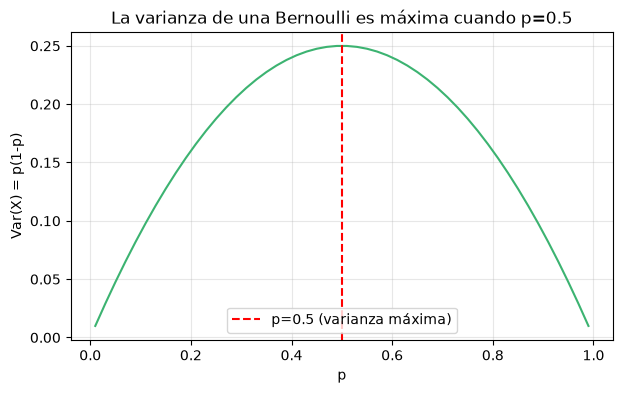

P(no vende) con p=0.35: 0.65


In [5]:
# Comparamos la varianza para distintos valores de p
p_valores = np.linspace(0.01, 0.99, 50)
varianzas = p_valores * (1 - p_valores)

plt.figure(figsize=(7, 4))
plt.plot(p_valores, varianzas, color='mediumseagreen')
plt.axvline(0.5, color='red', linestyle='--', label='p=0.5 (varianza máxima)')
plt.xlabel('p')
plt.ylabel('Var(X) = p(1-p)')
plt.title('La varianza de una Bernoulli es máxima cuando p=0.5')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("P(no vende) con p=0.35:", 1 - p)



## 1.3 Variable aleatoria Binomial

Cuenta el número de éxitos en $n$ ensayos Bernoulli independientes, cada uno con probabilidad de éxito $p$:

$$f_X(k) = \binom{n}{k}p^k(1-p)^{n-k}, \qquad k=0,1,\dots,n, \qquad X\sim \text{Bin}(n,p).$$

**Propiedades:** $\mathbb{E}[X]=np$, $\text{Var}(X)=np(1-p)$.

**Ejemplo.** En un control de calidad, se revisan $n=15$ artículos de una línea de producción donde la probabilidad de que un artículo salga defectuoso es $p=0.05$. Sea $X$ el número de artículos defectuosos.


E[X] = 0.75
Var(X) = 0.7125
P(X <= 1) = 0.829  -> probabilidad de que el lote pase el control


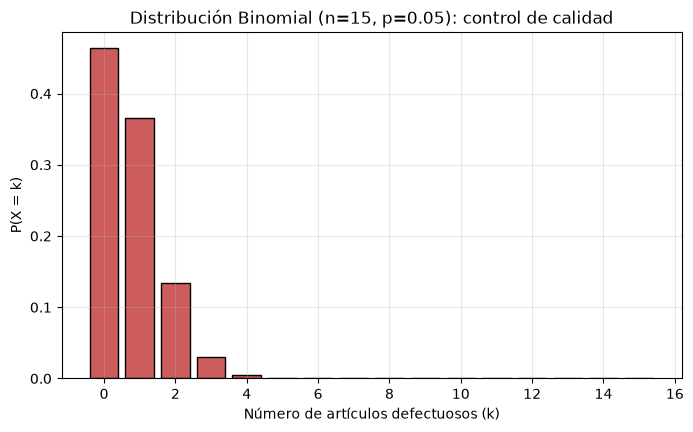

In [6]:
from scipy.stats import binom

n, p = 15, 0.05
X_vals = np.arange(0, n + 1)
pmf_bin = binom.pmf(X_vals, n, p)

# Probabilidad de que a lo mas 1 articulo salga defectuoso
prob_a_lo_mas_1 = binom.cdf(1, n, p)

print("E[X] =", binom.mean(n, p))
print("Var(X) =", round(binom.var(n, p), 4))
print("P(X <= 1) =", round(prob_a_lo_mas_1, 4), " -> probabilidad de que el lote pase el control")

plt.figure(figsize=(8, 4.5))
plt.bar(X_vals, pmf_bin, color='indianred', edgecolor='black')
plt.xlabel('Número de artículos defectuosos (k)')
plt.ylabel('P(X = k)')
plt.title(f'Distribución Binomial (n={n}, p={p}): control de calidad')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** Un examen tiene $n=20$ preguntas de opción múltiple, y un estudiante tiene probabilidad $p=0.7$ de contestar bien cada una (de forma independiente). ¿Cuál es la probabilidad de que apruebe si necesita al menos 12 respuestas correctas?


In [7]:
n2, p2 = 20, 0.7
prob_aprobar = 1 - binom.cdf(11, n2, p2)  # P(X >= 12) = 1 - P(X <= 11)

print("Con n=20 preguntas y p=0.7, P(aprobar, X>=12) =", round(prob_aprobar, 4))
print("E[X] =", n2 * p2, " -> en promedio, el estudiante contesta bien", n2 * p2, "preguntas")


Con n=20 preguntas y p=0.7, P(aprobar, X>=12) = 0.8867
E[X] = 14.0  -> en promedio, el estudiante contesta bien 14.0 preguntas



## 1.4 Variable aleatoria Geométrica

Cuenta el número de ensayos Bernoulli independientes necesarios **hasta obtener el primer éxito** (incluyendo ese ensayo), donde cada ensayo tiene probabilidad de éxito $p$:

$$f_X(k) = p(1-p)^{k-1}, \qquad k=1,2,3,\dots, \qquad X\sim\text{Geo}(p).$$

**Propiedades:** $\mathbb{E}[X]=\dfrac{1}{p}$, $\text{Var}(X)=\dfrac{1-p}{p^2}$.

**Ejemplo.** Un examen de Estadística consta de 20 preguntas, y un alumno tiene probabilidad $p=0.7$ de contestar bien cada una. ¿Cuál es la probabilidad de que la **primera** pregunta que contesta bien sea la **cuarta**?


P(X=4) = (1-p)^(k-1) * p = 0.018900
E[X] = 1.4286  -> en promedio, acierta la primera al 1.43 -esimo intento
Var(X) = 0.6122


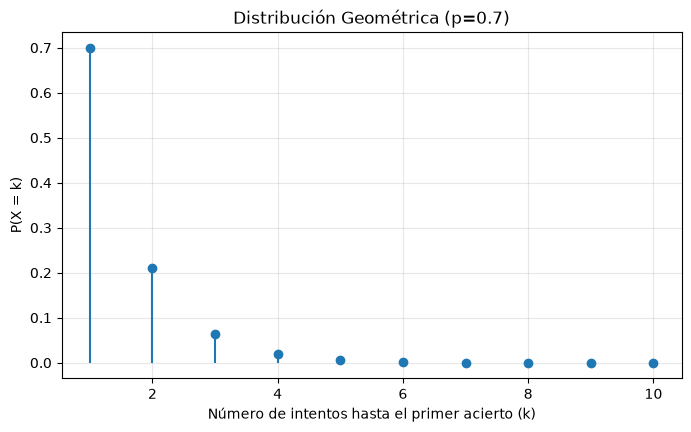

In [8]:
from scipy.stats import geom

p_geo = 0.7
k_geo = 4

prob_geo = geom.pmf(k_geo, p_geo)
print(f"P(X={k_geo}) = (1-p)^(k-1) * p = {prob_geo:.6f}")
print("E[X] =", round(geom.mean(p_geo), 4), " -> en promedio, acierta la primera al", round(geom.mean(p_geo), 2), "-esimo intento")
print("Var(X) =", round(geom.var(p_geo), 4))

x_geo = np.arange(1, 11)
pmf_vals = geom.pmf(x_geo, p_geo)

plt.figure(figsize=(8, 4.5))
plt.stem(x_geo, pmf_vals, basefmt=" ")
plt.xlabel('Número de intentos hasta el primer acierto (k)')
plt.ylabel('P(X = k)')
plt.title(f'Distribución Geométrica (p={p_geo})')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** Una compañía petrolera estima que un pozo exploratorio tiene 20% de probabilidad de encontrar petróleo ($p=0.2$). ¿Cuál es la probabilidad de que el primer pozo productivo sea el **tercero** que se perfora?


In [9]:
p_pozo = 0.2
prob_tercer_pozo = geom.pmf(3, p_pozo)
print("P(el primer pozo productivo es el 3o) =", round(prob_tercer_pozo, 4))


P(el primer pozo productivo es el 3o) = 0.128



## 1.5 Variable aleatoria Poisson

Modela el número de eventos "raros" que ocurren en un intervalo fijo (de tiempo, área, etc.), cuando estos eventos ocurren a una tasa promedio $\lambda>0$:

$$f_X(k)=e^{-\lambda}\frac{\lambda^k}{k!}, \qquad k=0,1,2,\dots, \qquad X\sim\text{Poisson}(\lambda).$$

**Propiedades:** $\mathbb{E}[X]=\lambda$, $\text{Var}(X)=\lambda$ (la media y la varianza son iguales, esto es una "huella digital" de la Poisson).

**Ejemplo.** El número de accidentes en un cruce sigue una distribución Poisson con $\lambda=2$ accidentes por día. ¿Cuál es la probabilidad de que ocurran **más de dos** accidentes en un día?


P(X > 2) = 0.3233
E[X] = Var(X) = 2


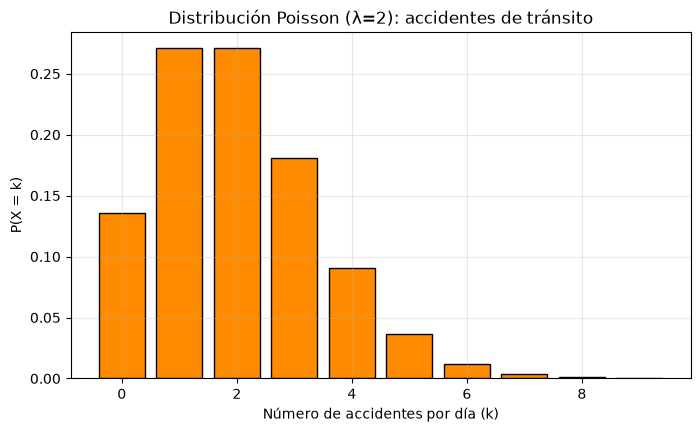

In [10]:
from scipy.stats import poisson

lam = 2
prob_mas_2 = 1 - poisson.cdf(2, lam)

print("P(X > 2) =", round(prob_mas_2, 4))
print("E[X] = Var(X) =", lam)

x_poi = np.arange(0, 10)
pmf_poi = poisson.pmf(x_poi, lam)

plt.figure(figsize=(8, 4.5))
plt.bar(x_poi, pmf_poi, color='darkorange', edgecolor='black')
plt.xlabel('Número de accidentes por día (k)')
plt.ylabel('P(X = k)')
plt.title(f'Distribución Poisson (λ={lam}): accidentes de tránsito')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** A un chat llegan en promedio $\lambda=3$ mensajes por minuto. Calcula $\mathbb{P}(X=2)$ y $\mathbb{P}(X\ge 5)$.


In [11]:
lam2 = 3
prob_2_mensajes = poisson.pmf(2, lam2)
prob_5_o_mas = 1 - poisson.cdf(4, lam2)

print("P(X=2) =", round(prob_2_mensajes, 4))
print("P(X>=5) =", round(prob_5_o_mas, 4))


P(X=2) = 0.224
P(X>=5) = 0.1847



## 1.6 Variable aleatoria Binomial Negativa

Generaliza a la geométrica: cuenta el número de ensayos $X$ necesarios para conseguir un total de $r$ éxitos (con probabilidad de éxito $p$ en cada ensayo):

$$f_X(k) = \binom{k-1}{r-1}p^r(1-p)^{k-r}, \qquad k=r,r+1,\dots, \qquad X\sim\text{BN}(r,p).$$

**Propiedades:** $\mathbb{E}[X]=\dfrac{r}{p}$, $\text{Var}(X)=\dfrac{r(1-p)}{p^2}$.

**Ejemplo.** En el examen de 20 preguntas ($p=0.7$), un alumno aprueba si contesta bien 10 preguntas. ¿Cuál es la probabilidad de que **apruebe justo al contestar la pregunta 12** (es decir, la décima respuesta correcta ocurre exactamente en el intento 12)?

*Nota:* `scipy.stats.nbinom` está parametrizada en términos del número de **fracasos** antes de los $r$ éxitos, por lo que si $X$ es el número total de ensayos, hay que evaluar en $X-r$.


P(X=12) = 0.139825
E[X] = r/p = 14.2857  -> en promedio necesita 14.29 preguntas para acertar 10
Var(X) = 6.1224


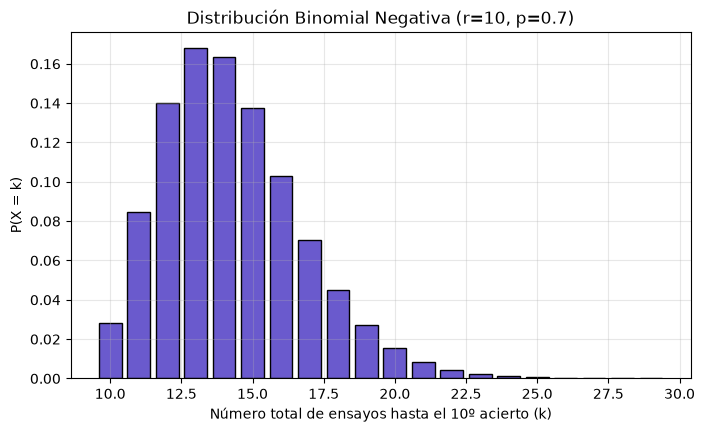

In [12]:
from scipy.stats import nbinom

r, p_bn = 10, 0.7
k_bn = 12  # ensayo total en el que ocurre el r-esimo exito

prob_bn = nbinom.pmf(k_bn - r, r, p_bn)  # nbinom cuenta "fracasos" = k - r
print(f"P(X={k_bn}) = {prob_bn:.6f}")
print("E[X] = r/p =", round(r / p_bn, 4), " -> en promedio necesita", round(r / p_bn, 2), "preguntas para acertar 10")
print("Var(X) =", round(r * (1 - p_bn) / p_bn ** 2, 4))

# Graficamos la distribucion (en terminos del numero total de ensayos)
x_bn = np.arange(r, r + 20)
pmf_bn_vals = nbinom.pmf(x_bn - r, r, p_bn)

plt.figure(figsize=(8, 4.5))
plt.bar(x_bn, pmf_bn_vals, color='slateblue', edgecolor='black')
plt.xlabel('Número total de ensayos hasta el 10º acierto (k)')
plt.ylabel('P(X = k)')
plt.title(f'Distribución Binomial Negativa (r={r}, p={p_bn})')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** Volviendo a los pozos petroleros ($p=0.2$): ¿cuál es la probabilidad de que el **tercer** pozo productivo se logre exactamente en el **séptimo** pozo perforado? Además, calcula la media y varianza del número de pozos que hay que perforar para conseguir 3 pozos productores.


In [13]:
r_pozo, p_pozo2 = 3, 0.2
k_pozo = 7

prob_septimo = nbinom.pmf(k_pozo - r_pozo, r_pozo, p_pozo2)
media_pozos = r_pozo / p_pozo2
var_pozos = r_pozo * (1 - p_pozo2) / p_pozo2 ** 2

print("P(el 3er pozo productivo es el 7o perforado) =", round(prob_septimo, 6))
print("Media de pozos a perforar   :", media_pozos)
print("Varianza de pozos a perforar:", var_pozos)


P(el 3er pozo productivo es el 7o perforado) = 0.049152
Media de pozos a perforar   : 15.0
Varianza de pozos a perforar: 60.0



## 1.7 Variable aleatoria Hipergeométrica

Se elige, **sin reemplazo**, una muestra de tamaño $n$ de una población de $N$ elementos, de los cuales $m$ son "de interés" (por ejemplo, rojos, defectuosos, etc.). Si $X$ es el número de elementos de interés obtenidos:

$$f_X(i) = \frac{\binom{m}{i}\binom{N-m}{n-i}}{\binom{N}{n}}, \qquad i = \max\{0,n-(N-m)\},\dots,\min\{n,m\}.$$

**Notación:** $X\sim\text{Hiper}(n,N,m)$.

**Propiedades:**
$$\mathbb{E}[X]=\frac{nm}{N}, \qquad \text{Var}(X)=n\frac{m}{N}\left(1-\frac{m}{N}\right)\frac{N-n}{N-1}.$$

A diferencia de la binomial, aquí los ensayos **no son independientes** (porque no hay reemplazo): sacar una bola roja cambia la probabilidad de sacar otra roja después.

**Ejemplo.** Una urna tiene $N=50$ bolas, de las cuales $m=20$ son rojas. Se extraen $n=10$ bolas sin reemplazo. Sea $X$ el número de bolas rojas obtenidas.


E[X] (scipy)   : 4.0  | E[X] (formula): 4.0
Var(X) (scipy) : 1.9592  | Var(X) (formula): 1.9592


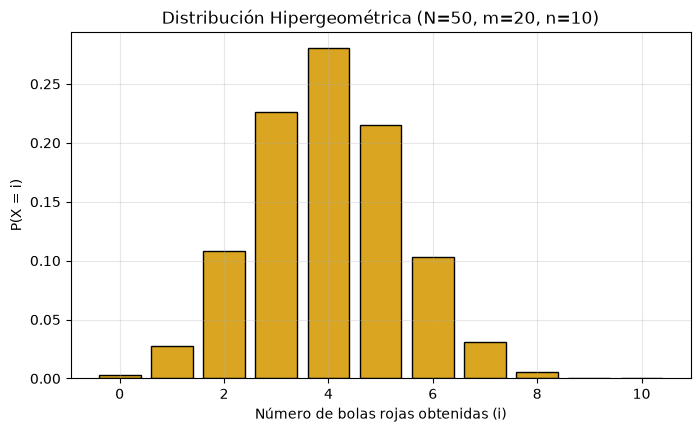

In [14]:
from scipy.stats import hypergeom

N_pob, m_exito, n_muestra = 50, 20, 10

# En scipy.stats.hypergeom los parametros son (M=poblacion total, n=exitos en la poblacion, N=tamano de muestra)
X_hiper = np.arange(0, n_muestra + 1)
pmf_hiper = hypergeom.pmf(X_hiper, N_pob, m_exito, n_muestra)

E_hiper = hypergeom.mean(N_pob, m_exito, n_muestra)
Var_hiper = hypergeom.var(N_pob, m_exito, n_muestra)

# Verificamos con la formula
E_formula_h = n_muestra * m_exito / N_pob
Var_formula_h = n_muestra * (m_exito / N_pob) * (1 - m_exito / N_pob) * (N_pob - n_muestra) / (N_pob - 1)

print("E[X] (scipy)   :", round(E_hiper, 4), " | E[X] (formula):", round(E_formula_h, 4))
print("Var(X) (scipy) :", round(Var_hiper, 4), " | Var(X) (formula):", round(Var_formula_h, 4))

plt.figure(figsize=(8, 4.5))
plt.bar(X_hiper, pmf_hiper, color='goldenrod', edgecolor='black')
plt.xlabel('Número de bolas rojas obtenidas (i)')
plt.ylabel('P(X = i)')
plt.title(f'Distribución Hipergeométrica (N={N_pob}, m={m_exito}, n={n_muestra})')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional.** De una baraja de 52 cartas (13 corazones), se extraen 5 cartas sin reemplazo. ¿Cuál es la probabilidad de obtener exactamente 2 corazones?


In [15]:
prob_2_corazones = hypergeom.pmf(2, 52, 13, 5)
print("P(exactamente 2 corazones en 5 cartas) =", round(prob_2_corazones, 4))


P(exactamente 2 corazones en 5 cartas) = 0.2743



### Conclusión de variables aleatorias discretas

Repasando todo esto me di cuenta de que casi todas parten de la misma idea base, un ensayo de éxito o fracaso (Bernoulli), y lo que cambia es qué le contamos a partir de ahí: si contamos éxitos en $n$ ensayos llegamos a la binomial, si contamos ensayos hasta que aparece el primer éxito (o el $r$-ésimo) llegamos a la geométrica o la binomial negativa, si contamos eventos raros en un intervalo de tiempo llegamos a la Poisson, y si contamos éxitos muestreando sin reemplazo llegamos a la hipergeométrica. Con esto ya me queda más fácil, ante un problema nuevo, pensar "¿qué estoy contando aquí?" y a partir de eso saber qué distribución me conviene usar.



# 2. Variables aleatorias continuas

Una **variable aleatoria continua** $X$ es aquella para la que existe una función $f_X\ge 0$, llamada **función de densidad**, tal que

$$F_X(x) = \mathbb{P}(X\le x) = \int_{-\infty}^{x} f_X(y)\,dy.$$

A diferencia del caso discreto, aquí $\mathbb{P}(X=x)=0$ para cualquier valor puntual $x$; solo tienen sentido las probabilidades sobre intervalos, es decir $\mathbb{P}(a\le X\le b) = F_X(b)-F_X(a)$.

Revisamos a continuación las distribuciones continuas más importantes.



## 2.1 Variable aleatoria uniforme continua

$X\sim\text{Unif}(a,b)$ si todos los valores del intervalo $(a,b)$ son "igual de probables" en el sentido de densidad constante:

$$f_X(x) = \frac{1}{b-a}, \quad a< x< b, \qquad F_X(x)=\frac{x-a}{b-a}, \quad a\le x\le b.$$

**Propiedades:** $\mathbb{E}[X]=\dfrac{a+b}{2}$, $\text{Var}(X)=\dfrac{(b-a)^2}{12}$.

**Ejemplo.** Sea $X\sim\text{Unif}(-3,2)$. Calculemos $\mathbb{P}(X\ge 0)$ y $\mathbb{P}(-5\le X\le 0.5)$, y grafiquemos su densidad y distribución.


P(X >= 0)          = 0.4
P(-5 <= X <= 0.5)  = 0.7
E[X] = -0.5  | Var(X) = 2.0833


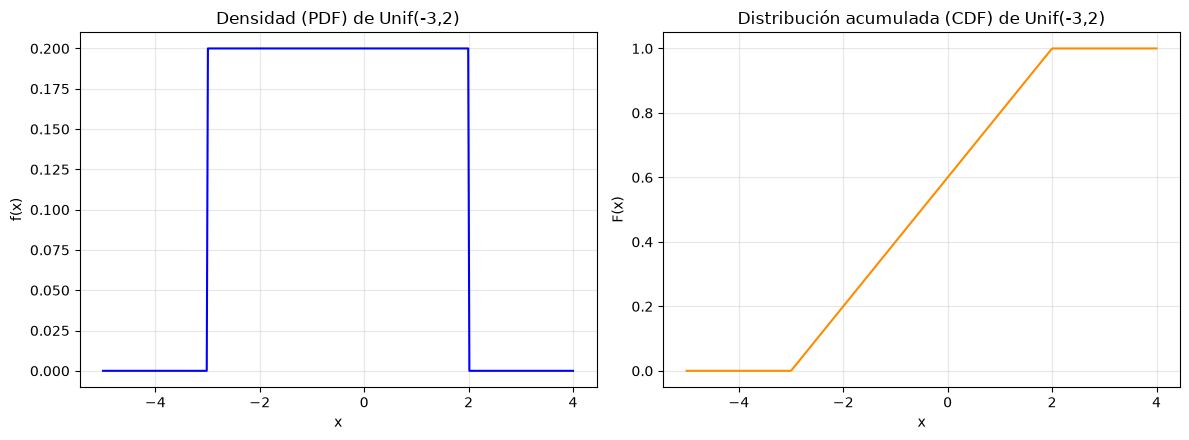

In [16]:
from scipy.stats import uniform

a, b = -3, 2
X_unif = uniform(loc=a, scale=b - a)

p1 = 1 - X_unif.cdf(0)
p2 = X_unif.cdf(0.5) - X_unif.cdf(-5)

print("P(X >= 0)          =", round(p1, 4))
print("P(-5 <= X <= 0.5)  =", round(p2, 4))
print("E[X] =", X_unif.mean(), " | Var(X) =", round(X_unif.var(), 4))

x_vals = np.linspace(-5, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_vals, X_unif.pdf(x_vals), color='blue')
axes[0].set_title('Densidad (PDF) de Unif(-3,2)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].grid(alpha=0.3)

axes[1].plot(x_vals, X_unif.cdf(x_vals), color='darkorange')
axes[1].set_title('Distribución acumulada (CDF) de Unif(-3,2)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



**Simulación.** Generamos muchos valores simulados de $\text{Unif}(-3,2)$ con `numpy`, y comparamos su histograma con la densidad teórica, además de comparar la media y varianza muestrales con las fórmulas.


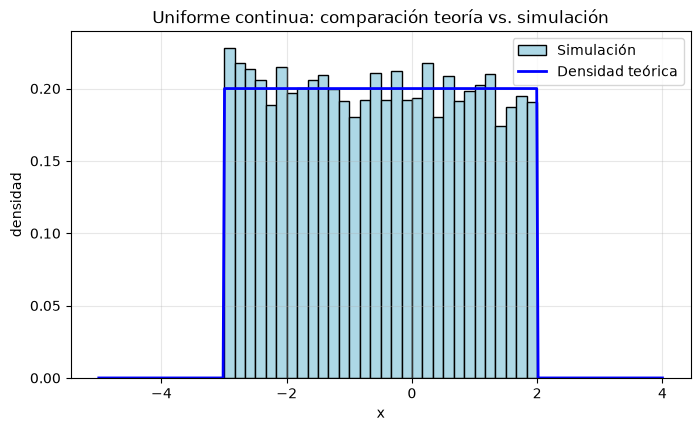

Media muestral : -0.5408  | Media teórica : -0.5
Varianza muestral: 2.0993  | Varianza teórica: 2.0833


In [17]:
np.random.seed(10)
muestra_unif = np.random.uniform(a, b, 10000)

plt.figure(figsize=(8, 4.5))
plt.hist(muestra_unif, bins=30, density=True, color='lightblue', edgecolor='black', label='Simulación')
plt.plot(x_vals, X_unif.pdf(x_vals), color='blue', linewidth=2, label='Densidad teórica')
plt.xlabel('x'); plt.ylabel('densidad')
plt.title('Uniforme continua: comparación teoría vs. simulación')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Media muestral :", round(muestra_unif.mean(), 4), " | Media teórica :", X_unif.mean())
print("Varianza muestral:", round(muestra_unif.var(), 4), " | Varianza teórica:", round(X_unif.var(), 4))



**Ejercicio adicional.** Un estudiante llega a la biblioteca y no está dispuesto a esperar más de 10 minutos. El tiempo de espera $X$ se modela como $\text{Unif}(0.5, 10)$. Calcula: la probabilidad de esperar entre 5 y 8 minutos, la esperanza y varianza, y $\mathbb{P}(2.51\le X\le 7.99)$.


In [18]:
a2, b2 = 0.5, 10
X_bib = uniform(loc=a2, scale=b2 - a2)

prob_5_8 = X_bib.cdf(8) - X_bib.cdf(5)
prob_intervalo = X_bib.cdf(7.99) - X_bib.cdf(2.51)

print("P(5 < X < 8)          =", round(prob_5_8, 4))
print("E[X] =", X_bib.mean(), " | Var(X) =", round(X_bib.var(), 4))
print("P(2.51 <= X <= 7.99)  =", round(prob_intervalo, 4))


P(5 < X < 8)          = 0.3158
E[X] = 5.25  | Var(X) = 7.5208
P(2.51 <= X <= 7.99)  = 0.5768



## 2.2 Variable aleatoria Normal

$X\sim N(\mu,\sigma^2)$ si su densidad es la conocida "campana de Gauss":

$$f_X(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}, \qquad x\in\mathbb{R}.$$

**Propiedades:** $\mathbb{E}[X]=\mu$, $\text{Var}(X)=\sigma^2$. Si $Z=\dfrac{X-\mu}{\sigma}$, entonces $Z\sim N(0,1)$ (normal estándar); esto permite calcular cualquier probabilidad usando la CDF de la normal estándar.

Es la distribución más importante de la estadística, gracias al Teorema Central del Límite (que veremos más adelante en este notebook).

**Ejemplo.** Si $X\sim N(3,2^2)$, calculemos $\mathbb{P}(X<2)$. Y si $Z\sim N(0,1)$, calculemos $\mathbb{P}(-1.93<Z<1.93)$.


P(X<2) con X~N(3,2^2)        : 0.3085
P(-1.93<Z<1.93) con Z~N(0,1) : 0.9464


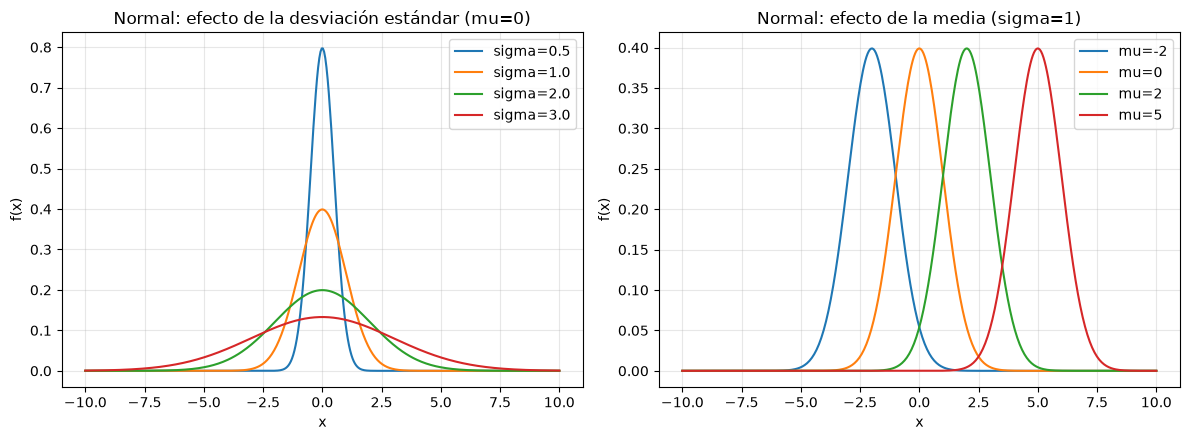

In [19]:
from scipy.stats import norm

p_normal_1 = norm.cdf(2, loc=3, scale=2)
p_normal_2 = norm.cdf(1.93) - norm.cdf(-1.93)

print("P(X<2) con X~N(3,2^2)        :", round(p_normal_1, 4))
print("P(-1.93<Z<1.93) con Z~N(0,1) :", round(p_normal_2, 4))

# Graficamos como cambia la forma de la campana al variar sigma y mu
x_vals = np.linspace(-10, 10, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for s in [0.5, 1.0, 2.0, 3.0]:
    axes[0].plot(x_vals, norm.pdf(x_vals, loc=0, scale=s), label=f'sigma={s}')
axes[0].set_title('Normal: efecto de la desviación estándar (mu=0)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(); axes[0].grid(alpha=0.3)

for m in [-2, 0, 2, 5]:
    axes[1].plot(x_vals, norm.pdf(x_vals, loc=m, scale=1), label=f'mu={m}')
axes[1].set_title('Normal: efecto de la media (sigma=1)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



**Simulación.** Generamos una muestra simulada de $X\sim N(3,2^2)$ y comparamos su histograma con la densidad teórica.


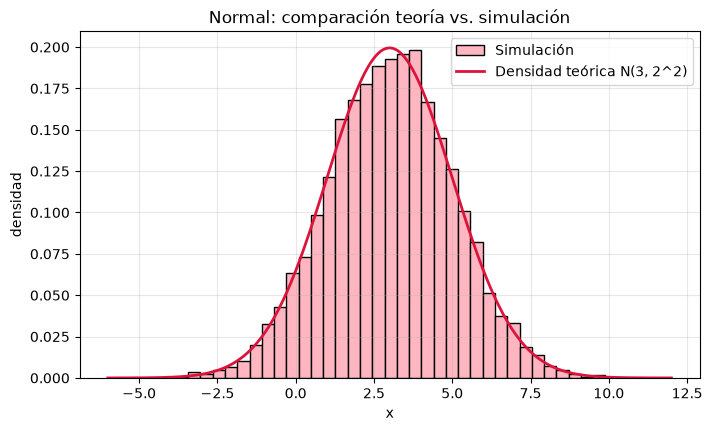

Media muestral : 3.0321  | Media teórica : 3
Varianza muestral: 4.0016  | Varianza teórica: 4


In [20]:
np.random.seed(20)
muestra_normal = np.random.normal(loc=3, scale=2, size=10000)

x_vals_n = np.linspace(-6, 12, 400)
plt.figure(figsize=(8, 4.5))
plt.hist(muestra_normal, bins=40, density=True, color='lightpink', edgecolor='black', label='Simulación')
plt.plot(x_vals_n, norm.pdf(x_vals_n, loc=3, scale=2), color='crimson', linewidth=2, label='Densidad teórica N(3, 2^2)')
plt.xlabel('x'); plt.ylabel('densidad')
plt.title('Normal: comparación teoría vs. simulación')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Media muestral :", round(muestra_normal.mean(), 4), " | Media teórica :", 3)
print("Varianza muestral:", round(muestra_normal.var(), 4), " | Varianza teórica:", 4)



**Ejercicio adicional.** La estatura de un grupo de estudiantes se modela como $X\sim N(170, 8^2)$ (en cm). ¿Cuál es la probabilidad de que un estudiante mida entre 160 y 180 cm?


In [21]:
prob_estatura = norm.cdf(180, loc=170, scale=8) - norm.cdf(160, loc=170, scale=8)
print("P(160 < estatura < 180) =", round(prob_estatura, 4))


P(160 < estatura < 180) = 0.7887



## 2.3 Variable aleatoria Exponencial

Modela el tiempo que transcurre hasta que ocurre un evento (tiempo entre llegadas, tiempo de vida de un componente), con tasa $\lambda>0$:

$$f_X(x)=\lambda e^{-\lambda x}, \; x>0, \qquad F_X(x)=1-e^{-\lambda x}, \; x\ge 0.$$

**Propiedades:** $\mathbb{E}[X]=\dfrac{1}{\lambda}$, $\text{Var}(X)=\dfrac{1}{\lambda^2}$.

**Propiedad de pérdida de memoria:** $\mathbb{P}(X>t+s\mid X>t)=\mathbb{P}(X>s)$: si el evento no ha ocurrido tras un tiempo $t$, la probabilidad de esperar $s$ más es la misma que esperarlo desde el inicio.

**Ejemplo.** En un banco, solo el 10% de las veces el tiempo entre la llegada de dos clientes supera los 2 minutos. Esto determina $\lambda$: de $\mathbb{P}(X>2)=0.1$ obtenemos $\lambda = -\ln(0.1)/2$. Calculemos después $\mathbb{P}(X>1)$.


lambda = 1.1513
P(X>1) = 0.3162
E[X] = 0.8686  | Var(X) = 0.7544


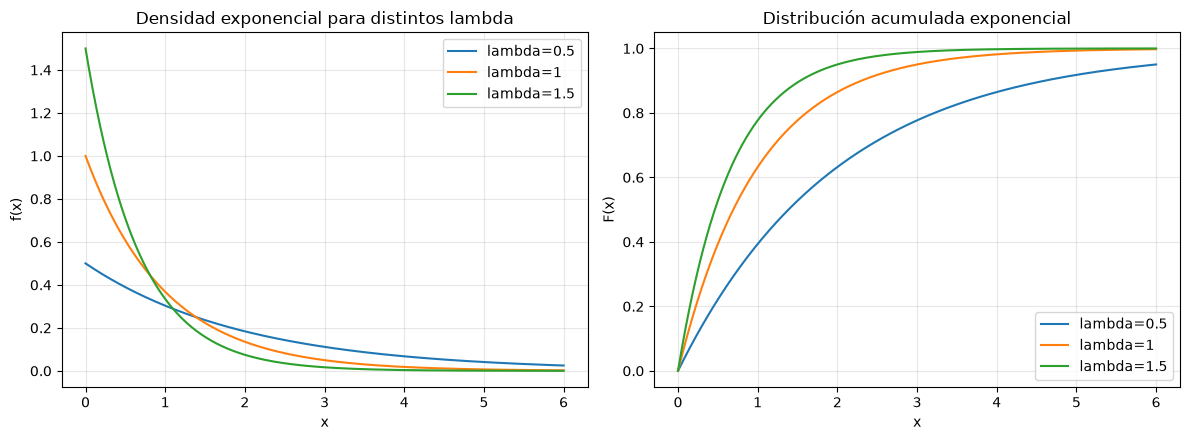

In [22]:
from scipy.stats import expon

lam = -np.log(0.1) / 2
X_exp = expon(scale=1 / lam)

print("lambda =", round(lam, 4))
print("P(X>1) =", round(X_exp.sf(1), 4))
print("E[X] =", round(X_exp.mean(), 4), " | Var(X) =", round(X_exp.var(), 4))

x_vals = np.linspace(0, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for l in [0.5, 1, 1.5]:
    axes[0].plot(x_vals, l * np.exp(-l * x_vals), label=f'lambda={l}')
axes[0].set_title('Densidad exponencial para distintos lambda')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(); axes[0].grid(alpha=0.3)

for l in [0.5, 1, 1.5]:
    axes[1].plot(x_vals, 1 - np.exp(-l * x_vals), label=f'lambda={l}')
axes[1].set_title('Distribución acumulada exponencial')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()



**Simulación.** Generamos una muestra simulada de $X\sim\text{Exp}(\lambda)$ (con el $\lambda$ que acabamos de encontrar) y la comparamos con la densidad teórica.


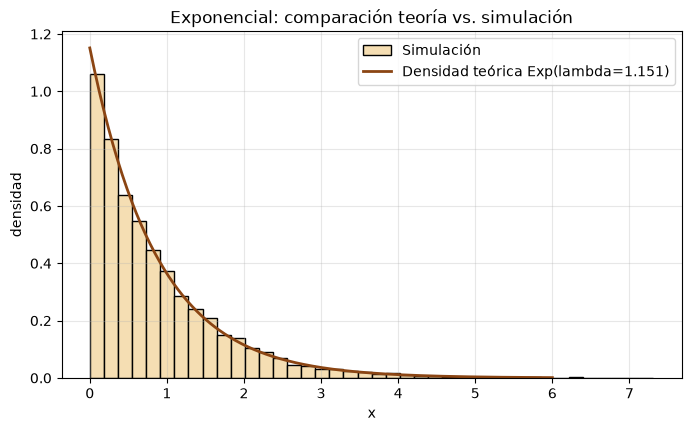

Media muestral : 0.8747  | Media teórica (1/lambda): 0.8686


In [23]:
np.random.seed(30)
muestra_exp = np.random.exponential(scale=1 / lam, size=10000)

x_vals_e = np.linspace(0, 6, 300)
plt.figure(figsize=(8, 4.5))
plt.hist(muestra_exp, bins=40, density=True, color='wheat', edgecolor='black', label='Simulación')
plt.plot(x_vals_e, lam * np.exp(-lam * x_vals_e), color='saddlebrown', linewidth=2, label=f'Densidad teórica Exp(lambda={lam:.3f})')
plt.xlabel('x'); plt.ylabel('densidad')
plt.title('Exponencial: comparación teoría vs. simulación')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Media muestral :", round(muestra_exp.mean(), 4), " | Media teórica (1/lambda):", round(1 / lam, 4))



**Ejercicio adicional.** El tiempo entre llegadas de clientes a una caja registradora es $X\sim\text{Exp}(\lambda)$, con un tiempo promedio de 3 minutos.

a) Encuentra $\lambda$.  b) $\mathbb{P}(X<2)$.  c) $\mathbb{P}(X>4)$.  d) $\mathbb{P}(2<X<6)$.


In [24]:
tiempo_promedio = 3
lam_caja = 1 / tiempo_promedio
X_caja = expon(scale=tiempo_promedio)

print("a) lambda =", round(lam_caja, 4))
print("b) P(X<2) =", round(X_caja.cdf(2), 4))
print("c) P(X>4) =", round(X_caja.sf(4), 4))
print("d) P(2<X<6) =", round(X_caja.cdf(6) - X_caja.cdf(2), 4))


a) lambda = 0.3333
b) P(X<2) = 0.4866
c) P(X>4) = 0.2636
d) P(2<X<6) = 0.3781



## 2.4 Variable aleatoria Gamma

Generaliza a la exponencial: modela el tiempo que transcurre hasta que ocurren $\alpha$ eventos de tipo Poisson con tasa $\lambda$. Su densidad es:

$$f_X(x) = \frac{\lambda^{\alpha}x^{\alpha-1}e^{-\lambda x}}{\Gamma(\alpha)}, \quad x>0, \qquad X\sim \Gamma(\alpha,\lambda).$$

**Propiedades:** $\mathbb{E}[X]=\dfrac{\alpha}{\lambda}$, $\text{Var}(X)=\dfrac{\alpha}{\lambda^2}$. Si $\alpha=1$, la Gamma se reduce a la exponencial.

**Ejemplo.** Un aparato de medición tiene un tiempo de vida exponencial con media de 1000 horas. Se usan 10 aparatos consecutivamente (uno tras otro). El tiempo total de vida $X$ de los 10 aparatos es $X\sim\Gamma(10, 0.001)$. ¿Cuál es la probabilidad de que, en conjunto, sigan funcionando después de 10,000 horas?


P(X > 10000) = 0.4579
E[X] = 10000.0  horas | Var(X) = 10000000.0


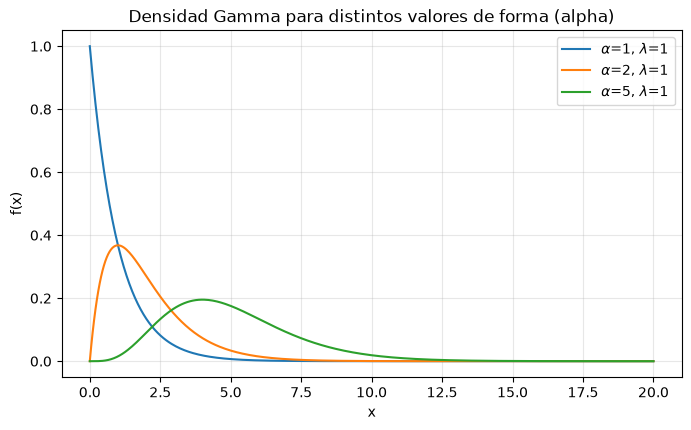

In [25]:
from scipy.stats import gamma

alpha, lam_g = 10, 0.001
X_gamma = gamma(a=alpha, scale=1 / lam_g)

prob_10000 = X_gamma.sf(10000)
print("P(X > 10000) =", round(prob_10000, 4))
print("E[X] =", X_gamma.mean(), " horas | Var(X) =", round(X_gamma.var(), 2))

x_vals = np.linspace(0, 20, 400)
plt.figure(figsize=(8, 4.5))
for a_ in [1, 2, 5]:
    plt.plot(x_vals, gamma.pdf(x_vals, a=a_, scale=1), label=fr'$\alpha$={a_}, $\lambda$=1')
plt.title('Densidad Gamma para distintos valores de forma (alpha)')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional (comparación teoría vs. simulación).** Un resultado interesante es que si $Z\sim N(0,1)$, entonces $Z^2\sim \Gamma\left(\frac12,\frac12\right)$. Vamos a comprobarlo simulando muchos valores de $Z^2$ y comparando su histograma con la densidad teórica Gamma(1/2, 1/2).


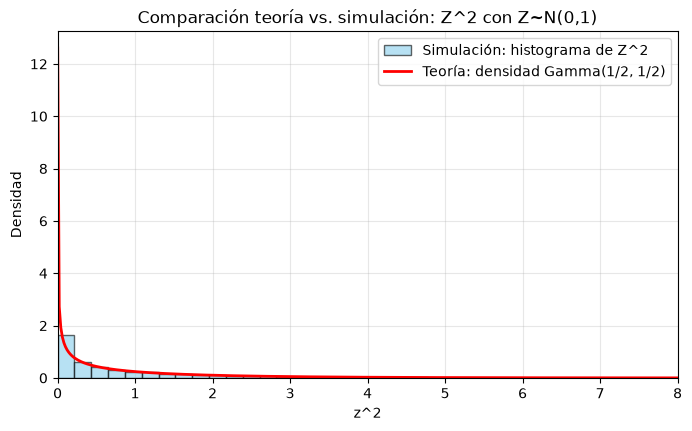

Media simulada de Z^2: 1.0001  (teórica: alpha/lambda = 1)


In [26]:
np.random.seed(1)
Z = np.random.normal(0, 1, 20000)
Z2 = Z ** 2

x_vals = np.linspace(0.001, 8, 400)
densidad_teorica = gamma.pdf(x_vals, a=0.5, scale=2)  # Gamma(alpha=1/2, lambda=1/2) -> scale=1/lambda=2

plt.figure(figsize=(8, 4.5))
plt.hist(Z2, bins=80, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Simulación: histograma de Z^2')
plt.plot(x_vals, densidad_teorica, color='red', linewidth=2, label=r'Teoría: densidad Gamma(1/2, 1/2)')
plt.xlim(0, 8)
plt.xlabel('z^2'); plt.ylabel('Densidad')
plt.title('Comparación teoría vs. simulación: Z^2 con Z~N(0,1)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Media simulada de Z^2:", round(Z2.mean(), 4), " (teórica: alpha/lambda = 1)")



El histograma de las simulaciones de $Z^2$ le queda encima a la densidad teórica Gamma(1/2, 1/2), así que el resultado se confirma. Esto también me sirvió para ver que la Gamma no es una distribución aislada, sino que sale de forma natural al combinar o transformar otras (exponenciales, normales), como una especie de familia.

### Conclusión de variables aleatorias continuas

Viendo las cuatro juntas, quedan bastante conectadas entre sí: la uniforme continua es la base para poder simular cualquier otra distribución (eso lo vamos a usar en la siguiente sección), la exponencial sirve para modelar tiempos de espera que "no tienen memoria" del pasado, la Gamma es como una generalización de la exponencial cuando esperamos varios eventos y no solo uno, y la normal termina apareciendo como el límite al que tienden muchas otras distribuciones cuando promediamos muchos datos, que es justo lo que dice el Teorema Central del Límite más adelante.



# 3. Simulación de variables aleatorias

Para poder simular cualquier variable aleatoria en una computadora, primero necesitamos generar números **pseudoaleatorios uniformes** en $(0,1)$ (la base de todo), y después transformarlos para que sigan la distribución que nos interesa.

## 3.1 Generación de números pseudoaleatorios uniformes

Se llaman *pseudoaleatorios* porque, aunque se ven aleatorios, se generan con una fórmula determinística de recurrencia. Dos métodos clásicos son:

- **Método congruencial multiplicativo:** $n_{i+1} = a\, n_i \bmod m$.
- **Método congruencial mixto:** $n_{i+1} = (a\, n_i + c) \bmod m$.

En ambos casos, dividimos $n_{i+1}$ entre $m$ para obtener un número en $(0,1)$. Hoy en día, en la práctica usamos generadores ya optimizados como `numpy.random`, pero es importante entender el principio detrás de ellos.


In [27]:
def congruencial_multiplicativo(n0, a, m, n):
    # Genera n numeros pseudoaleatorios en (0,1) con la formula n_(i+1) = a*n_i mod m
    secuencia = []
    ni = n0
    for _ in range(n):
        ni = (a * ni) % m
        secuencia.append(ni / m)
    return secuencia

def congruencial_mixto(n0, a, c, m, n):
    # Genera n numeros pseudoaleatorios en (0,1) con la formula n_(i+1) = (a*n_i + c) mod m
    secuencia = []
    ni = n0
    for _ in range(n):
        ni = (a * ni + c) % m
        secuencia.append(ni / m)
    return secuencia

# Ejemplo con el metodo multiplicativo
m = 2 ** 31
a = 65539       # cumple a = +-3 (mod 8)
n0 = 123456789
secuencia_mult = congruencial_multiplicativo(n0, a, m, 10)
print("Primeros 10 numeros (metodo multiplicativo):")
print([round(v, 4) for v in secuencia_mult])

# Ejemplo con el metodo mixto
a2 = 1103515245  # cumple a = 1 (mod 4)
c2 = 12345
secuencia_mixto = congruencial_mixto(41, a2, c2, m, 10)
print("Primeros 10 numeros (metodo mixto):")
print([round(v, 4) for v in secuencia_mixto])


Primeros 10 numeros (metodo multiplicativo):
[0.7747, 0.1306, 0.8117, 0.6946, 0.8622, 0.922, 0.7723, 0.3358, 0.0637, 0.3599]
Primeros 10 numeros (metodo mixto):
[0.0684, 0.9992, 0.4621, 0.9175, 0.582, 0.3782, 0.2048, 0.1848, 0.4875, 0.8469]


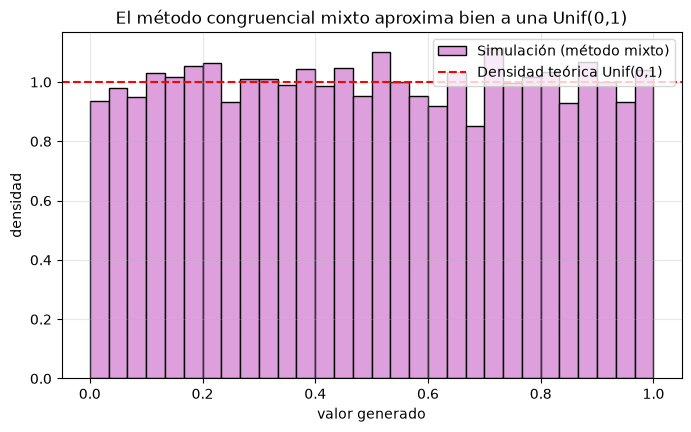

In [28]:
# Comparacion teoria vs simulacion: generamos muchos numeros y verificamos
# que se distribuyen aproximadamente uniforme en (0,1)
muestra_grande = congruencial_mixto(41, a2, c2, m, 10000)

plt.figure(figsize=(8, 4.5))
plt.hist(muestra_grande, bins=30, density=True, color='plum', edgecolor='black', label='Simulación (método mixto)')
plt.axhline(1.0, color='red', linestyle='--', label='Densidad teórica Unif(0,1)')
plt.xlabel('valor generado'); plt.ylabel('densidad')
plt.title('El método congruencial mixto aproxima bien a una Unif(0,1)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()



## 3.2 Método de la transformada inversa

Este método permite generar cualquier variable aleatoria $X$ a partir de una $U\sim\text{Unif}(0,1)$, usando la inversa de su función de distribución:

$$\textbf{Teorema.} \quad \text{Si } U\sim\text{Unif}(0,1) \text{ y } F_X \text{ es estrictamente creciente, entonces } X = F_X^{-1}(U) \text{ tiene la misma ley que } X.$$

Veamos tres ejemplos: una Bernoulli, una exponencial y una Cauchy.

**a) Bernoulli.** Si $U\le p$, definimos éxito (1); si no, fracaso (0).


In [29]:
import random

def bernoulli_por_inversion(p):
    # Genera una Bernoulli(p) a partir de una uniforme U
    U = random.random()
    return 1 if U <= p else 0

random.seed(123)
p_sim = 0.3
n_sim = 10000
muestra_ber = [bernoulli_por_inversion(p_sim) for _ in range(n_sim)]

print("Proporcion de exitos simulada:", sum(muestra_ber) / n_sim, " (teorica: p =", p_sim, ")")


Proporcion de exitos simulada: 0.2978  (teorica: p = 0.3 )



**b) Exponencial.** Como $F_X(x) = 1-e^{-\lambda x}$, despejando obtenemos $X = -\dfrac{\ln(U)}{\lambda}$ (usamos que $U$ y $1-U$ tienen la misma distribución).


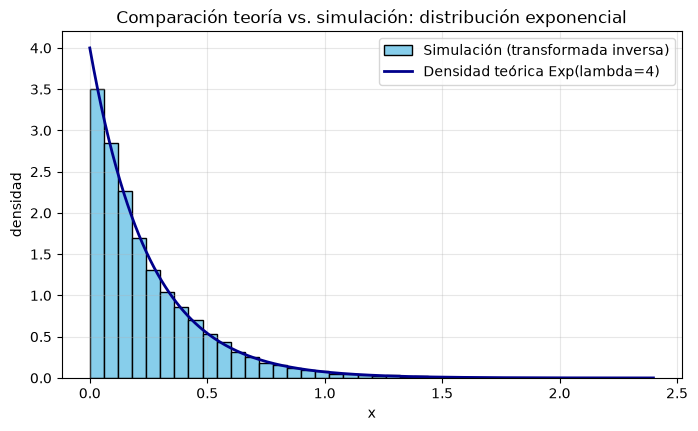

Media simulada: 0.2494  | Media teórica (1/lambda): 0.25


In [30]:
np.random.seed(123)
lambd = 4
n_exp = 20000

U = np.random.random(n_exp)
X_simulada = -np.log(U) / lambd  # transformada inversa

x_vals = np.linspace(0, X_simulada.max(), 300)
densidad_teorica = lambd * np.exp(-lambd * x_vals)

plt.figure(figsize=(8, 4.5))
plt.hist(X_simulada, bins=40, density=True, color='skyblue', edgecolor='black', label='Simulación (transformada inversa)')
plt.plot(x_vals, densidad_teorica, color='darkblue', linewidth=2, label=f'Densidad teórica Exp(lambda={lambd})')
plt.xlabel('x'); plt.ylabel('densidad')
plt.title('Comparación teoría vs. simulación: distribución exponencial')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Media simulada:", round(X_simulada.mean(), 4), " | Media teórica (1/lambda):", round(1 / lambd, 4))



**c) Cauchy.** La densidad de la Cauchy estándar es $f_X(x)=\dfrac{1}{\pi}\dfrac{1}{1+x^2}$, con $F_X(x) = \dfrac{1}{\pi}\arctan(x)+\dfrac12$. Despejando: $X = \tan\!\big(\pi(U-\tfrac12)\big)$.


Integral de la densidad de Cauchy en toda la recta: 1.0 (debe ser 1)


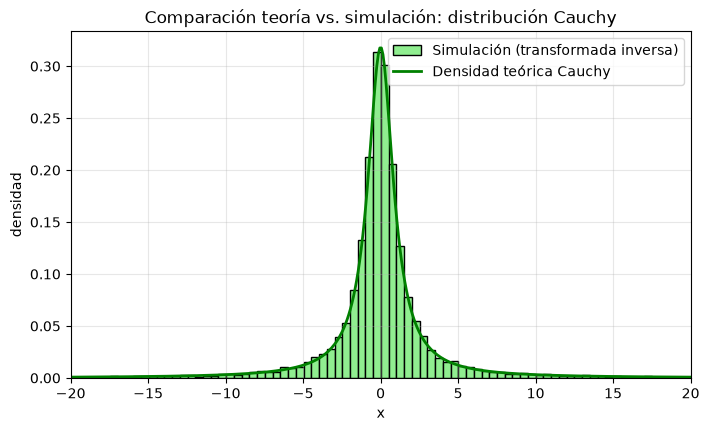

Estadistico KS = 0.0038, p-valor = 0.9333
Conclusion: no se rechaza que la muestra siga una Cauchy


In [31]:
from scipy import integrate
from scipy.stats import kstest

def pdf_cauchy(x):
    return (1 / np.pi) * (1 / (1 + x ** 2))

def cdf_cauchy(x):
    return (1 / np.pi) * np.arctan(x) + 0.5

# Verificamos que en efecto es una densidad valida (el area total es 1)
integral, _ = integrate.quad(pdf_cauchy, -np.inf, np.inf)
print("Integral de la densidad de Cauchy en toda la recta:", round(integral, 6), "(debe ser 1)")

# Generamos la muestra por transformada inversa
np.random.seed(42)
n_cauchy = 20000
U = np.random.random(n_cauchy)
X_cauchy = np.tan(np.pi * (U - 0.5))

# Para graficar, recortamos los valores muy extremos (la Cauchy tiene colas muy pesadas)
X_cauchy_recortada = X_cauchy[(X_cauchy > -20) & (X_cauchy < 20)]

x_vals = np.linspace(-20, 20, 400)
plt.figure(figsize=(8, 4.5))
plt.hist(X_cauchy_recortada, bins=80, density=True, color='lightgreen', edgecolor='black', label='Simulación (transformada inversa)')
plt.plot(x_vals, pdf_cauchy(x_vals), color='green', linewidth=2, label='Densidad teórica Cauchy')
plt.xlim(-20, 20)
plt.xlabel('x'); plt.ylabel('densidad')
plt.title('Comparación teoría vs. simulación: distribución Cauchy')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Prueba de bondad de ajuste de Kolmogorov-Smirnov
ks_stat, p_value = kstest(X_cauchy, cdf_cauchy)
print(f"Estadistico KS = {ks_stat:.4f}, p-valor = {p_value:.4f}")
print("Conclusion:", "no se rechaza que la muestra siga una Cauchy" if p_value > 0.05 else "se rechaza el ajuste Cauchy")



En los tres casos que probé (Bernoulli, exponencial, Cauchy) partí nada más de números uniformes en (0,1) y les apliqué la inversa de la distribución que quería simular, y en los tres las muestras generadas terminaron pareciéndose a la teoría, ya fuera viéndolo a ojo (histograma contra densidad) o de forma más formal con la prueba de Kolmogorov-Smirnov. Y esa es básicamente la lógica detrás de casi cualquier simulación estadística que uno haga en la práctica.



# 4. Función generadora de momentos (FGM)

La **función generadora de momentos** de una variable aleatoria $X$ se define como:

$$M_X(t) = \mathbb{E}\left[e^{tX}\right],$$

siempre que esta esperanza exista para $t$ en un intervalo alrededor de $0$.

**Propiedades:**

1. $M_X(0)=1$ siempre.
2. Los momentos de $X$ se obtienen derivando y evaluando en $t=0$:
$$\mathbb{E}[X] = M_X'(0), \qquad \mathbb{E}[X^2]=M_X''(0), \qquad \text{en general } \mathbb{E}[X^k]=M_X^{(k)}(0).$$
3. Si $X$ y $Y$ son independientes, $M_{X+Y}(t) = M_X(t)\cdot M_Y(t)$.
4. Si dos variables aleatorias tienen la misma FGM (en un intervalo alrededor de 0), entonces tienen la misma distribución (la FGM identifica de forma única a la distribución, cuando existe).

**Ejemplo 1 (Bernoulli).** Si $X\sim\text{Ber}(p)$:
$$M_X(t) = \mathbb{E}[e^{tX}] = (1-p)e^{0}+p\,e^{t} = (1-p)+p\,e^{t}.$$

Vamos a obtener $\mathbb{E}[X]$ y $\text{Var}(X)$ derivando numéricamente esta función en $t=0$ (en vez de derivar a mano), y comparar con las fórmulas que ya conocemos ($\mathbb{E}[X]=p$, $\text{Var}(X)=p(1-p)$).


In [32]:
def derivadas_en_cero(f, h=1e-4):
    # Aproxima la primera y segunda derivada de f en t=0 usando diferencias finitas centradas
    d1 = (f(h) - f(-h)) / (2 * h)
    d2 = (f(h) - 2 * f(0) + f(-h)) / (h ** 2)
    return d1, d2

# FGM de la Bernoulli(p)
p_mgf = 0.35
mgf_bernoulli = lambda t: (1 - p_mgf) + p_mgf * np.exp(t)

d1, d2 = derivadas_en_cero(mgf_bernoulli)
E_X = d1                 # E[X] = M'(0)
E_X2 = d2                # E[X^2] = M''(0)
Var_X = E_X2 - E_X ** 2

print("Usando la FGM (derivadas numericas):")
print("  E[X]   =", round(E_X, 4), " (formula: p =", p_mgf, ")")
print("  E[X^2] =", round(E_X2, 4))
print("  Var(X) =", round(Var_X, 4), " (formula: p(1-p) =", round(p_mgf * (1 - p_mgf), 4), ")")


Usando la FGM (derivadas numericas):
  E[X]   = 0.35  (formula: p = 0.35 )
  E[X^2] = 0.35
  Var(X) = 0.2275  (formula: p(1-p) = 0.2275 )



**Ejemplo 2 (Exponencial).** Si $X\sim\text{Exp}(\lambda)$, se puede demostrar que $M_X(t) = \dfrac{\lambda}{\lambda-t}$ para $t<\lambda$. Repetimos el mismo procedimiento numérico.


Usando la FGM (derivadas numericas):
  E[X]   = 0.6667  (formula: 1/lambda = 0.6667 )
  Var(X) = 0.4444  (formula: 1/lambda^2 = 0.4444 )


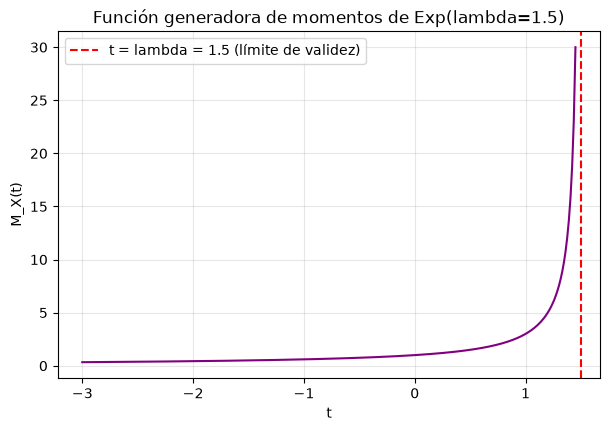

In [33]:
lam_mgf = 1.5
mgf_exponencial = lambda t: lam_mgf / (lam_mgf - t)

d1e, d2e = derivadas_en_cero(mgf_exponencial)
E_Xe = d1e
E_X2e = d2e
Var_Xe = E_X2e - E_Xe ** 2

print("Usando la FGM (derivadas numericas):")
print("  E[X]   =", round(E_Xe, 4), " (formula: 1/lambda =", round(1 / lam_mgf, 4), ")")
print("  Var(X) =", round(Var_Xe, 4), " (formula: 1/lambda^2 =", round(1 / lam_mgf ** 2, 4), ")")

# Graficamos la FGM de la exponencial en su region de validez (t < lambda)
t_vals = np.linspace(-3, lam_mgf - 0.05, 300)
plt.figure(figsize=(7, 4.5))
plt.plot(t_vals, mgf_exponencial(t_vals), color='purple')
plt.axvline(lam_mgf, color='red', linestyle='--', label=f't = lambda = {lam_mgf} (límite de validez)')
plt.xlabel('t'); plt.ylabel('M_X(t)')
plt.title(f'Función generadora de momentos de Exp(lambda={lam_mgf})')
plt.legend(); plt.grid(alpha=0.3)
plt.show()



En los dos ejemplos, al derivar numéricamente la FGM en $t=0$ me dan exactamente la misma esperanza y varianza que ya había calculado con las fórmulas de siempre. Eso me convenció de para qué sirve la FGM en realidad: en lugar de andar sacando esperanza, varianza y demás momentos por separado, con una sola función ya tengo guardada toda esa información.



# 5. Función característica (FC)

La **función característica** de $X$ se define como:

$$\varphi_X(t) = \mathbb{E}\left[e^{itX}\right], \qquad t\in\mathbb{R}, \quad i=\sqrt{-1}.$$

**Propiedades:**

1. $\varphi_X(0)=1$ y $|\varphi_X(t)|\le 1$ para todo $t$.
2. A diferencia de la FGM, la función característica **siempre existe** (no depende de que existan los momentos), porque $|e^{itX}|=1$ está acotado.
3. $\varphi_X$ determina de manera única a la distribución de $X$ (teorema de inversión).
4. Relación con los momentos: $\varphi_X^{(k)}(0) = i^k\,\mathbb{E}[X^k]$.

**Ejemplo (Normal estándar).** Se puede demostrar que si $Z\sim N(0,1)$, entonces

$$\varphi_Z(t) = e^{-t^2/2}.$$

Curiosamente, en este caso $\varphi_Z$ resulta ser una función **real** (sin parte imaginaria), gracias a la simetría de la normal. Vamos a usarla para recuperar $\mathbb{E}[Z]$ y $\mathbb{E}[Z^2]$ mediante diferenciación numérica.


E[Z]  (via FC) = 0.0  (teorico: 0)
E[Z^2] (via FC) = 1.0  (teorico: Var(Z)=1)


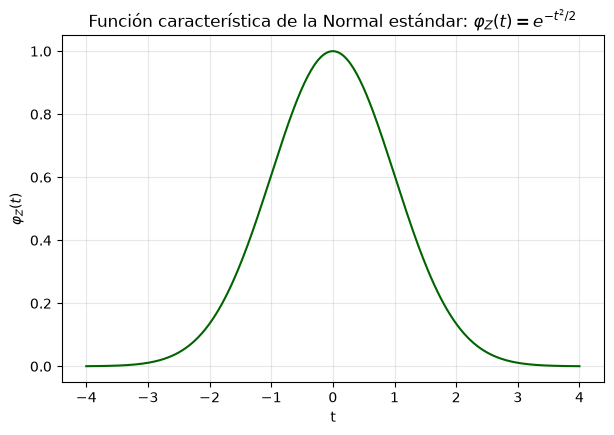

In [34]:
def derivadas_complejas_en_cero(f, h=1e-4):
    d1 = (f(h) - f(-h)) / (2 * h)
    d2 = (f(h) - 2 * f(0) + f(-h)) / (h ** 2)
    return d1, d2

phi_normal = lambda t: np.exp(-t ** 2 / 2) + 0j  # forzamos tipo complejo

d1z, d2z = derivadas_complejas_en_cero(phi_normal)

# phi'(0) = i*E[Z]  ->  E[Z] = phi'(0) / i
E_Z = (d1z / 1j).real
# phi''(0) = -E[Z^2]  ->  E[Z^2] = -phi''(0)
E_Z2 = (-d2z).real

print("E[Z]  (via FC) =", round(E_Z, 4), " (teorico: 0)")
print("E[Z^2] (via FC) =", round(E_Z2, 4), " (teorico: Var(Z)=1)")

t_vals = np.linspace(-4, 4, 300)
plt.figure(figsize=(7, 4.5))
plt.plot(t_vals, np.exp(-t_vals ** 2 / 2), color='darkgreen')
plt.xlabel('t'); plt.ylabel(r'$\varphi_Z(t)$')
plt.title('Función característica de la Normal estándar: $\\varphi_Z(t)=e^{-t^2/2}$')
plt.grid(alpha=0.3)
plt.show()



**Ejercicio adicional (Exponencial).** Para $X\sim\text{Exp}(\lambda)$ se sabe que $\varphi_X(t) = \dfrac{\lambda}{\lambda - it}$. Repetimos el procedimiento para obtener $\mathbb{E}[X]$ y $\mathbb{E}[X^2]$.


In [35]:
lam_fc = 1.5
phi_exp = lambda t: lam_fc / (lam_fc - 1j * t)

d1x, d2x = derivadas_complejas_en_cero(phi_exp)
E_X_fc = (d1x / 1j).real
E_X2_fc = (-d2x).real

print("E[X]   (via FC) =", round(E_X_fc, 4), " (teorico: 1/lambda =", round(1 / lam_fc, 4), ")")
print("E[X^2] (via FC) =", round(E_X2_fc, 4), " (teorico: 2/lambda^2 =", round(2 / lam_fc ** 2, 4), ")")


E[X]   (via FC) = 0.6667  (teorico: 1/lambda = 0.6667 )
E[X^2] (via FC) = 0.8889  (teorico: 2/lambda^2 = 0.8889 )



La función característica hace básicamente lo mismo que la FGM para sacar momentos, solo que tiene una ventaja extra: siempre existe, incluso para distribuciones raras como la Cauchy (la que vimos en la sección de simulación), que ni siquiera tiene FGM ni momentos finitos, pero función característica sí tiene.



# 6. Ley de los Grandes Números (LGN)

La **Ley de los Grandes Números** es uno de los resultados más importantes de la probabilidad, y es la justificación teórica detrás de todas las simulaciones que hemos hecho en este y en el notebook anterior.

**Idea central.** Si $X_1, X_2, \dots, X_n$ son variables aleatorias independientes e idénticamente distribuidas (iid), con esperanza finita $\mathbb{E}[X_i]=\mu$, entonces el promedio muestral

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n}X_i$$

**converge a $\mu$** conforme $n\to\infty$.

En otras palabras: mientras más observaciones promediemos, más se acerca ese promedio al valor esperado teórico. Esto es exactamente lo que vimos, de manera intuitiva, en el enfoque frecuentista del Notebook 1 (con el volado). Ahora lo repetimos con una distribución continua para reforzar la idea.

**Ejemplo.** Simulamos varias secuencias independientes de una variable $X\sim\text{Exp}(\lambda=1/3)$ (con media $\mu=3$), y observamos cómo el promedio acumulado de cada secuencia se estabiliza alrededor de $\mu=3$.


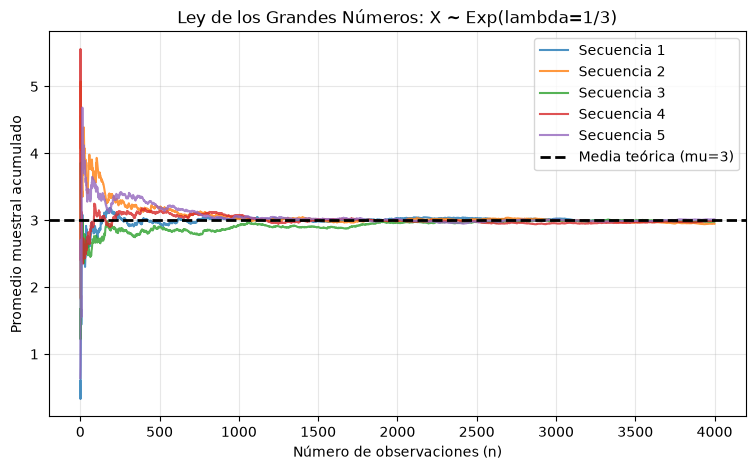

In [36]:
np.random.seed(11)

mu_teorica = 3
n_obs = 4000
n_secuencias = 5

plt.figure(figsize=(9, 5))
for i in range(n_secuencias):
    datos = np.random.exponential(scale=mu_teorica, size=n_obs)
    promedio_acumulado = np.cumsum(datos) / np.arange(1, n_obs + 1)
    plt.plot(promedio_acumulado, alpha=0.8, label=f'Secuencia {i+1}')

plt.axhline(mu_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica (mu=3)')
plt.xlabel('Número de observaciones (n)')
plt.ylabel('Promedio muestral acumulado')
plt.title('Ley de los Grandes Números: X ~ Exp(lambda=1/3)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Aunque cada secuencia arranca distinto (porque los primeros valores simulados son aleatorios y ahí sí pueden andar dispersos), las cinco terminan asentándose alrededor de la media teórica $\mu=3$ conforme $n$ crece. Eso es justo lo que garantiza la Ley de los Grandes Números, y por eso en la práctica podemos confiar en estimar un promedio poblacional usando una muestra suficientemente grande, idea que voy a retomar en el Notebook 3 cuando hable de estimadores.



# 7. Teorema Central del Límite (TCL)

Mientras que la Ley de los Grandes Números nos dice **hacia dónde** converge el promedio muestral, el **Teorema Central del Límite** nos dice **cómo se comporta** ese promedio para $n$ grande, sin importar la distribución original de los datos.

**Idea central.** Si $X_1,\dots,X_n$ son iid con esperanza $\mu$ y varianza $\sigma^2$ finitas, entonces para $n$ suficientemente grande:

$$\bar{X}_n \; \approx \; N\!\left(\mu, \frac{\sigma^2}{n}\right), \qquad \text{equivalentemente} \qquad \frac{\bar{X}_n-\mu}{\sigma/\sqrt{n}} \; \xrightarrow{d} \; N(0,1).$$

Lo notable es que esto ocurre **sin importar la forma de la distribución original** de $X_i$ (no tiene que ser normal). Vamos a comprobarlo partiendo de una distribución claramente no normal: la exponencial (que es muy asimétrica).

**Simulación.** Tomamos $X\sim\text{Exp}(\lambda=1/3)$ (con $\mu=3$, $\sigma^2=9$). Para distintos tamaños de muestra $n$, generamos 5000 muestras de tamaño $n$, calculamos la media de cada una, y graficamos el histograma de esas medias muestrales junto con la densidad normal teórica $N(\mu,\sigma^2/n)$.


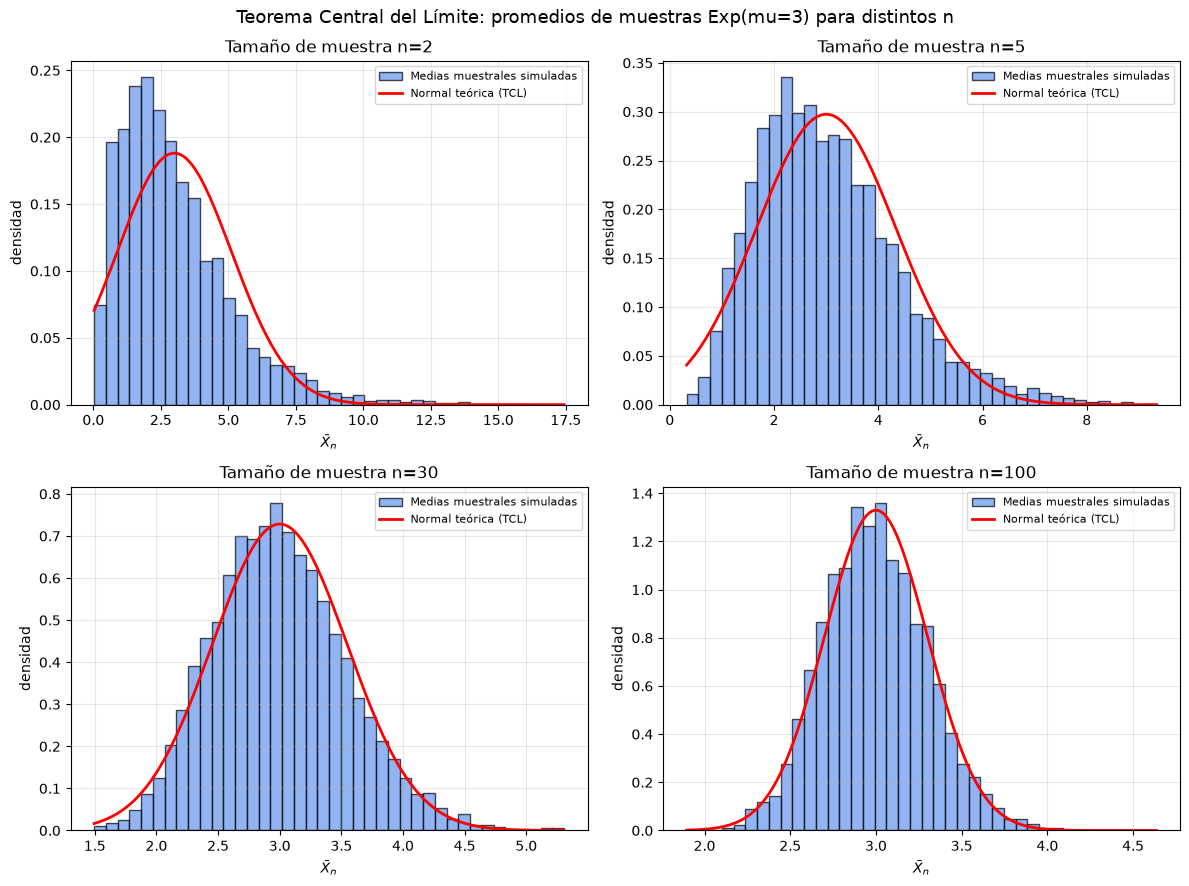

In [37]:
np.random.seed(99)

mu, sigma2 = 3, 9
tamanos_muestra = [2, 5, 30, 100]
n_repeticiones = 5000

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, n in zip(axes, tamanos_muestra):
    medias_muestrales = [np.mean(np.random.exponential(scale=mu, size=n)) for _ in range(n_repeticiones)]

    ax.hist(medias_muestrales, bins=40, density=True, color='cornflowerblue',
            edgecolor='black', alpha=0.7, label='Medias muestrales simuladas')

    x_vals = np.linspace(min(medias_muestrales), max(medias_muestrales), 200)
    densidad_normal = st.norm.pdf(x_vals, loc=mu, scale=np.sqrt(sigma2 / n))
    ax.plot(x_vals, densidad_normal, color='red', linewidth=2, label='Normal teórica (TCL)')

    ax.set_title(f'Tamaño de muestra n={n}')
    ax.set_xlabel(r'$\bar{X}_n$')
    ax.set_ylabel('densidad')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Teorema Central del Límite: promedios de muestras Exp(mu=3) para distintos n', fontsize=13)
plt.tight_layout()
plt.show()



Con $n=2$ la distribución de las medias muestrales todavía se ve bastante chueca, se nota que hereda la forma de la exponencial. Pero conforme $n$ va creciendo (5, 30, 100) el histograma se va poniendo cada vez más parecido a una campana normal, tal cual lo predice el TCL, y con $n=100$ el parecido ya es muy bueno.

Esto es clave para lo que viene: en el Notebook 3 voy a poder construir intervalos de confianza para la media usando la normal (o la t de Student) aunque no sepa si los datos originales son normales, mientras la muestra sea razonablemente grande.



## Conclusión

Armando este notebook fui construyendo, poco a poco, las herramientas principales para trabajar con variables aleatorias. Las distribuciones discretas y continuas terminan siendo los "moldes" que uso para describir un fenómeno aleatorio concreto (un conteo, un tiempo de espera, un número de éxitos), y elegir cuál usar depende sobre todo de cómo está planteado el experimento. Con la simulación, y en particular con el método de la transformada inversa, pude generar en la computadora cualquier variable aleatoria a partir de simples números uniformes, y comprobar que la teoría sí cuadra con la práctica.

La FGM y la FC me sirvieron como un atajo: en vez de calcular esperanza, varianza y demás por separado, con derivar una sola función ya tengo toda esa información, y la FC tiene la ventaja extra de existir siempre, hasta en casos raros como la Cauchy donde ni la esperanza está definida. Por su parte, la Ley de los Grandes Números explica por qué un promedio muestral se estabiliza cerca de la esperanza teórica cuando la muestra crece, y el Teorema Central del Límite explica por qué la normal aparece tan seguido en estadística: los promedios de muestras grandes terminan pareciéndose a una normal sin importar de qué distribución vinieron los datos originales.
